C:\Users\jakes\AppData\Local\Temp\ipykernel_14632\3761816105.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(TICKER, start=start_date, end=end_date, progress=False)
C:\Users\jakes\AppData\Local\Temp\ipykernel_14632\3761816105.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mean_return = float(log_return.mean())
C:\Users\jakes\AppData\Local\Temp\ipykernel_14632\3761816105.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  std_return = float(log_return.std())
C:\Users\jakes\AppData\Local\Temp\ipykernel_14632\3761816105.py:38: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  starting_price = float(prices.iloc[-1])



Historical Statistics for AAPL:
Time Period is 2026-04-06 22:20:20.187445 - 2021-02-01 22:20:20.187445
Mean Daily Return: 0.0632%
Daily Volatility: 1.7223%
Annualized Return: 15.93%
Annualized Volatility: 27.34%

Simulation Results:
Current Price: $258.86
Expected Price (Median): $287.35
5th Percentile: $184.35
95th Percentile: $444.00
Expected Return: 11.01%

Visualization saved as 'monte_carlo_simulation.png'


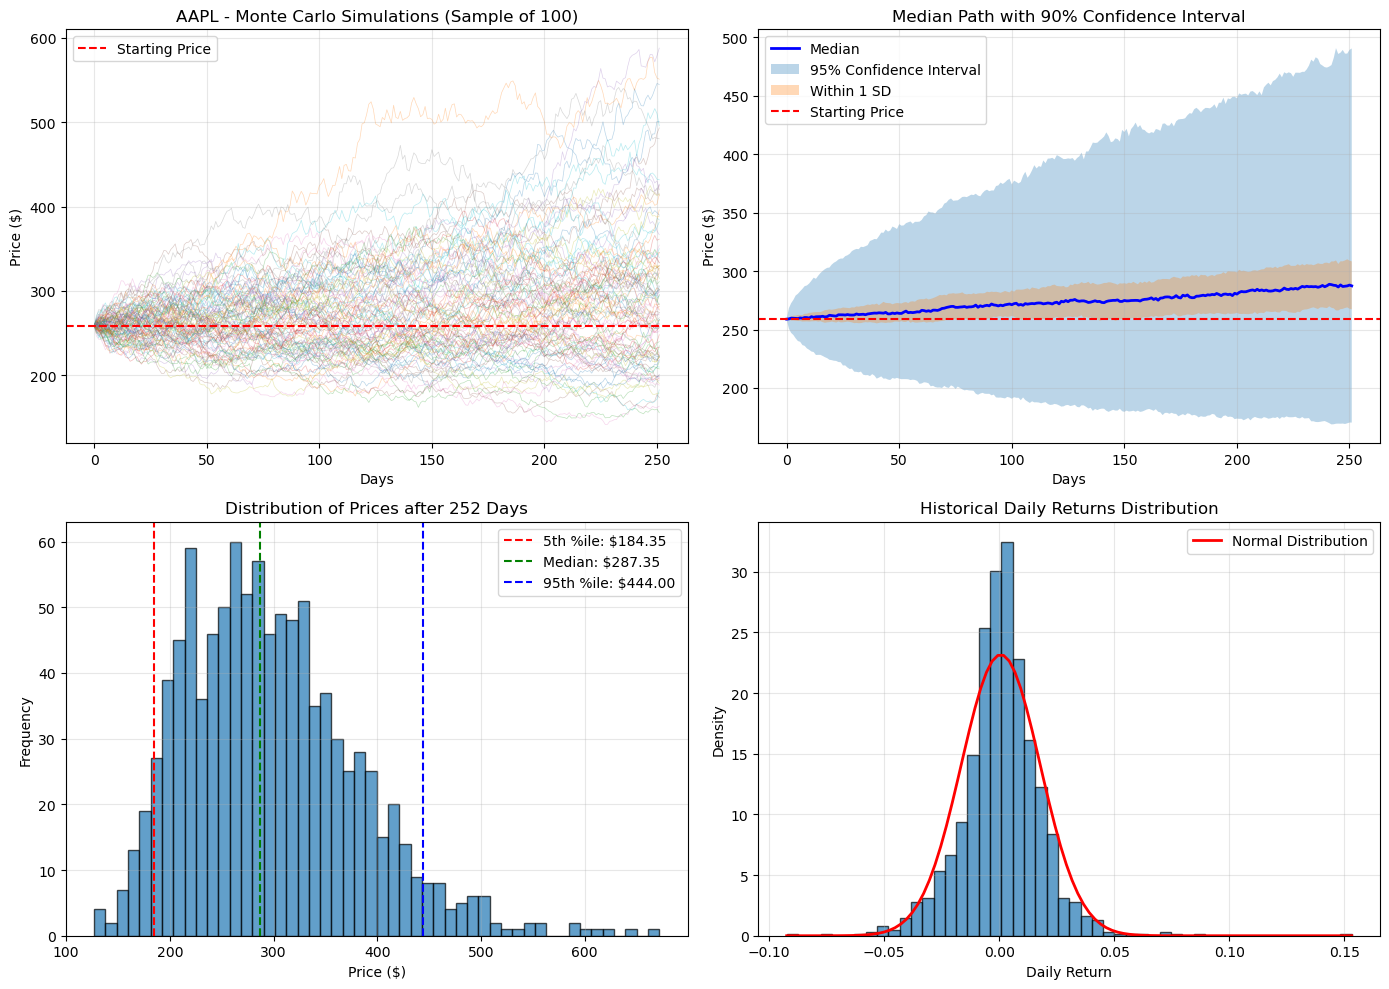

In [49]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


TICKER = "AAPL"  # Stock ticker input
DAYS_HISTORY = 252  * 5
SIMULATION_DAYS = 252 
NUM_SIMULATIONS = 1000  

print(f"Downloading {TICKER} data...")
end_date = datetime.now()
start_date = end_date - timedelta(days=int(DAYS_HISTORY * 1.5))  # Extra buffer for weekends
stock_data = yf.download(TICKER, start=start_date, end=end_date, progress=False)
prices = stock_data['Close'].dropna()
prices = prices[-DAYS_HISTORY:]  


returns = prices.pct_change().dropna()


mean_return = float(returns.mean())
std_return = float(returns.std())

print(f"\nHistorical Statistics for {TICKER}:")
print(f"Time Period is {end_date} - {start_date}") 
print(f"Mean Daily Return: {mean_return:.4%}")
print(f"Daily Volatility: {std_return:.4%}")
print(f"Annualized Return: {mean_return * 252:.2%}")
print(f"Annualized Volatility: {std_return * np.sqrt(252):.2%}")


# Initialize array to store all simulation paths
simulations = np.zeros((SIMULATION_DAYS, NUM_SIMULATIONS))
starting_price = float(prices.iloc[-1])

# Run simulations
for sim in range(NUM_SIMULATIONS):
    price_path = [starting_price]
    
    for day in range(SIMULATION_DAYS - 1):
        # Sample from normal distribution Markov property: next state depends only on current state
        daily_return = np.random.normal(mean_return, std_return)
        new_price = price_path[-1] * (1 + daily_return)
        price_path.append(new_price)
    
    simulations[:, sim] = price_path


final_prices = simulations[-1, :]
percentile_5 = np.percentile(final_prices, 5)
percentile_50 = np.percentile(final_prices, 50)
percentile_95 = np.percentile(final_prices, 95)

print(f"\nSimulation Results:")
print(f"Current Price: ${starting_price:.2f}")
print(f"Expected Price (Median): ${percentile_50:.2f}")
print(f"5th Percentile: ${percentile_5:.2f}")
print(f"95th Percentile: ${percentile_95:.2f}")
print(f"Expected Return: {((percentile_50 / starting_price) - 1) * 100:.2f}%")


# Plots
plt.figure(figsize=(14, 10))


plt.subplot(2, 2, 1)
sample_size = 100
plt.plot(simulations[:, :sample_size], alpha=0.3, linewidth=0.5)
plt.axhline(y=starting_price, color='r', linestyle='--', label='Starting Price')
plt.title(f'{TICKER} - Monte Carlo Simulations (Sample of {sample_size})')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)


plt.subplot(2, 2, 2)
median_path = np.percentile(simulations, 50, axis=1)
lower_bound = np.percentile(simulations, 2.5, axis=1)
lower_bound_40 = np.percentile(simulations, 40, axis = 1)
upper_bound = np.percentile(simulations, 97.5, axis=1)
upper_bound_60 = np.percentile(simulations, 60, axis = 1)

plt.plot(median_path, color='blue', linewidth=2, label='Median')
plt.fill_between(range(SIMULATION_DAYS), lower_bound, upper_bound, alpha=0.3, label='95% Confidence Interval')
plt.fill_between(range(SIMULATION_DAYS), lower_bound_40, upper_bound_60, alpha = 0.3, label = 'Within 1 SD')
plt.axhline(y=starting_price, color='r', linestyle='--', label='Starting Price')
plt.title('Median Path with 90% Confidence Interval')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)


plt.subplot(2, 2, 3)
plt.hist(final_prices, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(percentile_5, color='r', linestyle='--', label=f'5th %ile: ${percentile_5:.2f}')
plt.axvline(percentile_50, color='g', linestyle='--', label=f'Median: ${percentile_50:.2f}')
plt.axvline(percentile_95, color='b', linestyle='--', label=f'95th %ile: ${percentile_95:.2f}')
plt.title(f'Distribution of Prices after {SIMULATION_DAYS} Days')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)


plt.subplot(2, 2, 4)
plt.hist(returns, bins=50, edgecolor='black', alpha=0.7, density=True)
x = np.linspace(returns.min(), returns.max(), 100)
plt.plot(x, (1/(std_return * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mean_return)/std_return)**2), 
         'r-', linewidth=2, label='Normal Distribution')
plt.title('Historical Daily Returns Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('monte_carlo_simulation.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved as 'monte_carlo_simulation.png'")
plt.show()
